In [263]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle as pkl
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
import plotly.graph_objects as go

In [159]:
group_num  = 4
df = pkl.load( open(os.path.join('group_'+str(group_num)+'.pkl'), 'rb'))

df.head()

,temperature,humidity,machine performance
0,38.959688,19.117151,569.946353
1,26.595406,1.251856,105.706933
2,3.263655,30.824490,205.119059
3,10.592782,0.622938,32.488363
4,5.543941,44.797843,426.813872


<div dir="rtl">

## במפעל רוצים לבדוק כיצד המז"א אוויר משפיע על התפקוד של המכונות. 

### רוצים לבדוק כיצד הטמפרטורה במפעל והלחות משפיעים על התפקוד שלה.

### תפקוד המכונה מחושב לפי משתנה שנקרא machine performence. זה משתנה רציף שמקבל ערכים חיוביים. ככל שהוא יותר גבוה כך התפקוד של המכונה  טוב יותר. 


<div dir="rtl">

# שאלות:
## לפני הסעיפים הנ"ל יש לחלק את הנתונים 70%  train ו 30% test. 

## 1. נא לעשות רגרסיה ליניארית פשוטה ללא אינטרקציה וללא פולינומים בעזרת המשתנים tempeture וhumidity. 
## יש לבדוק את הנחות המודל ולהציג את המקדמים של המשוואה.

## 2. נא להראות גרף שציר ה x שלו הם ערכי ה machine perforemce האמיתיים  וציר הy שלו אלו הערכים החזויים מהמשוואה הליניארית . האם זה נראה שהתחזיות מדויקות לפי הגרף?

## 3. יש לבנות מודל ליניארי נוסף אך כעת יש לכלול אינטראקציה בין שני המשתנים המסבירים. איזה מודל יותר מדויק עם האינטראקיצה או ללא האינטראקציה.

## 4. עבור המודל עם האינטראקציה, בכמה משתנה machine perforemce עם מעלים את המשתנה humidity באחד עבור טמפרטורה  10?
### נא להסביר איך ניתן לדעת זאת דרך הטבלה של המקדמים. 

## 5. רגרסיה פולינימיאלית: בהנחה ומותר להכניס למודל משתנים עד פולינום בדרגה 5, מהו המודל הכי טוב שאתם יכולים למצוא?
### יש להשוות את המודל הזה למודלים הפשוטים יותר מסעיפים 1 ו-3. האם המדדים שהשתמשתם להשוואה השתפרו או נחלשו? 

## 6. מבין כל המשתנים שנכנסו למודל, איזה יש לו הכי הרבה השפעה על machine perforemce? לפי מה חישבתם את זה? יש לנמק  

### 7. נא להציג גרף שמראה את הMSE של הtrain set כפונקציה של גובה הפולינום. כלומר כל פעם מכניסים את כל המשתנים עד לדרגת הפולינום הנוכחית ובודקים את הMSE. נא להסביר את התוצאה שהתקבלה.


# בהצלחה!!!!!

In [160]:
df.dtypes

temperature            float64
humidity               float64
machine performance    float64
dtype: object

In [161]:
df.describe()

,temperature,humidity,machine performance
count,200.000000,200.000000,200.000000
mean,17.705058,24.673429,383.071238
std,11.813637,14.689091,283.335928
min,0.007873,0.210206,7.116359
25%,6.799354,10.870277,143.400264
50%,16.284984,24.143357,335.453971
75%,27.857937,38.260012,569.365425
max,39.582998,49.541817,1222.586273


In [162]:
df.isna().sum()

temperature            0
humidity               0
machine performance    0
dtype: int64

In [163]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   temperature          200 non-null    float64
 1   humidity             200 non-null    float64
 2   machine performance  200 non-null    float64
dtypes: float64(3)
memory usage: 4.8 KB


In [165]:
df.duplicated().sum()

0

<Axes: >

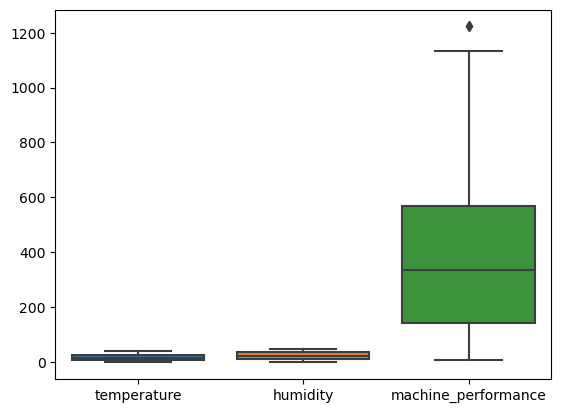

In [260]:
sns.boxplot(data=df)

In [166]:
X = df[['temperature', 'humidity']]
y = df['machine performance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# <span style="color:#1F4E79">מבוא</span>
בעבודה זו נבחן הקשר בין טמפרטורה ולחות לבין ביצועי מכונה באמצעות מודלי רגרסיה לינאריים ופולינומיים.  
השאלה המרכזית היא האם קיימים רכיבים לא־לינאריים או אינטראקציות המשפרים את איכות ההתאמה והחיזוי.  
לשם כך הושוו מודלים בדרגות מורכבות שונות תוך שימוש במדדי התאמה, מדדי חיזוי ובדיקות הנחות סטטיסטיות.

<div>
<img src="https://raw.githubusercontent.com/NirAvrahamoff/Regression-Analysis-for-Safety-Management/5c42f5de293cdb9a44da41dc61a65abdddad2562/Gemini_Generated_Image_9234jd9234jd9234.png" width="700"/>
</div>

# <span style="color:#1F4E79">סעיף 1 – מודל רגרסיה לינארית ללא אינטראקציה</span>

In [167]:
# הוספת קבוע
X_train_const = sm.add_constant(X_train)

# בניית המודל
model_linear = sm.OLS(y_train, X_train_const).fit()

# סיכום המודל
print(model_linear.summary())

                             OLS Regression Results                            
Dep. Variable:     machine performance   R-squared:                       0.923
Model:                             OLS   Adj. R-squared:                  0.922
Method:                  Least Squares   F-statistic:                     817.0
Date:                 Wed, 04 Mar 2026   Prob (F-statistic):           7.31e-77
Time:                         16:06:28   Log-Likelihood:                -810.95
No. Observations:                  140   AIC:                             1628.
Df Residuals:                      137   BIC:                             1637.
Df Model:                            2                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const        -249.0437     16.511    -15

## Linear Regression Equation

The fitted linear model is:

$$
\hat{Y} = -249.04 + 15.18 \cdot temperature + 14.71 \cdot humidity
$$

where

$$
Y = \text{machine performance}
$$

Thus, the predicted machine performance is a linear function of temperature and humidity.

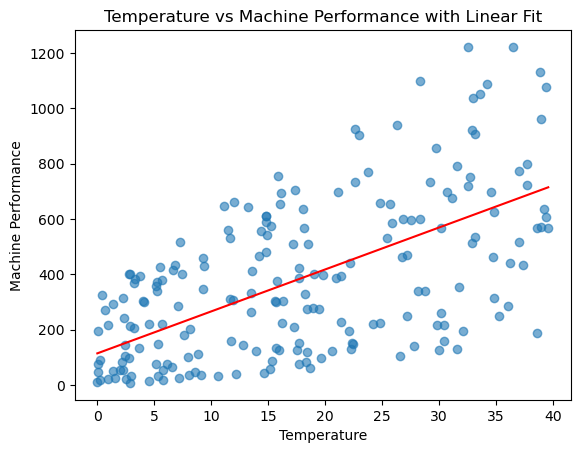

In [187]:
# גרף פיזור + קו רגרסיה לינארי עבור temperature

plt.scatter(df['temperature'], df['machine performance'], alpha=0.6)

# חישוב קו הרגרסיה לפי המודל שבנינו
temp_range = np.linspace(df['temperature'].min(), df['temperature'].max(), 100)
humidity_mean = df['humidity'].mean()

params = model_linear.params

plt.plot(temp_range, y_line, color='red')
plt.xlabel("Temperature")
plt.ylabel("Machine Performance")
plt.title("Temperature vs Machine Performance with Linear Fit")
plt.show()

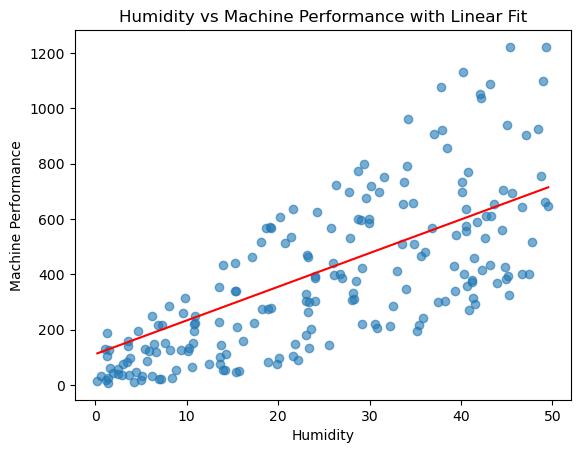

In [188]:
# גרף פיזור + קו רגרסיה לינארי עבור humidity

plt.scatter(df['humidity'], df['machine performance'], alpha=0.6)

humidity_range = np.linspace(df['humidity'].min(), df['humidity'].max(), 100)
temperature_mean = df['temperature'].mean()

params = model_linear.params

plt.plot(humidity_range, y_line, color='red')
plt.xlabel("Humidity")
plt.ylabel("Machine Performance")
plt.title("Humidity vs Machine Performance with Linear Fit")
plt.show()

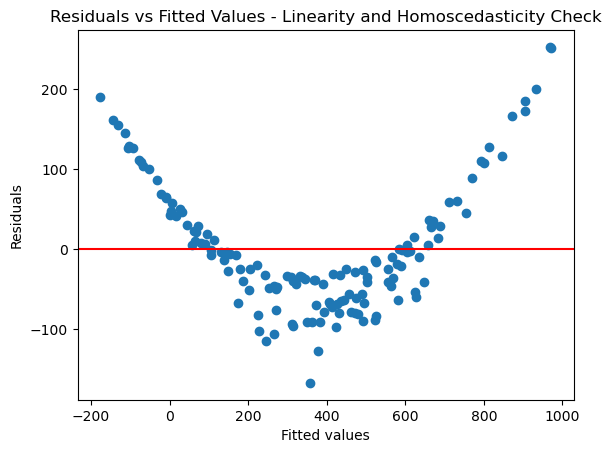

In [170]:
plt.scatter(model_linear.fittedvalues, model_linear.resid)
plt.axhline(0, color='red')
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values - Linearity and Homoscedasticity Check")
plt.show()

### בדיקת לינאריות והומוסקדסטיות – גרף Residuals vs Fitted

בגרף השאריות מול הערכים החזויים נצפתה תבנית בצורת U.

תבנית זו מעידה כי הקשר בין המשתנים המסבירים לבין המשתנה המוסבר אינו לינארי לחלוטין.  
במודל לינארי תקין היינו מצפים לראות פיזור אקראי של השאריות סביב 0 ללא תבנית ברורה.

קיומה של צורת U מצביע על כך שהמודל הלינארי הבסיסי אינו מתאר באופן מלא את הקשר,  
וייתכן כי נדרש להוסיף אינטראקציה או איברים פולינומיים על מנת לשפר את ההתאמה.

מסקנה: הנחת הלינאריות אינה מתקיימת באופן מלא במודל הבסיסי.

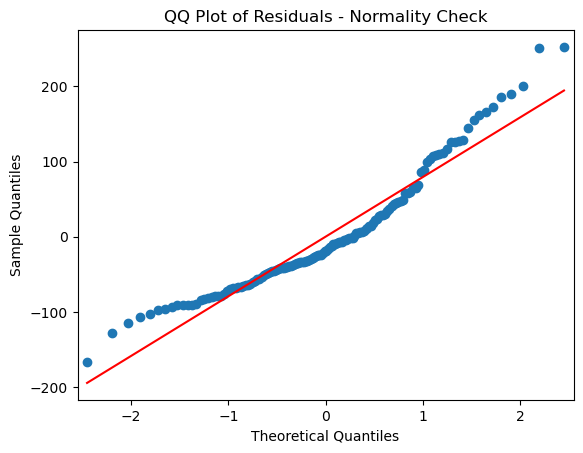

In [171]:
sm.qqplot(model_linear.resid, line='s')
plt.title("QQ Plot of Residuals - Normality Check")
plt.show()

### בדיקת נורמליות השאריות – QQ Plot

בוצע גרף QQ לצורך בדיקת האם השאריות מתפלגות בקירוב נורמלית.
    
אם רואים צורה “קשתית”/“משפך” בגרף השאריות - יש רמז לחוסר ליניאריות
QQ-Plot: סטיות חזקות מהקו = שאריות לא נורמליות

בגרף מושווים ערכי השאריות בפועל לערכים שהיינו מצפים לראות אם הן היו מתפלגות נורמלית.  
כאשר הנקודות קרובות לקו האלכסוני, ניתן להסיק כי ההנחה מתקיימת בקירוב.  
סטייה מהקו, במיוחד בקצוות, עשויה להעיד על חריגה מהנחת הנורמליות.

עם זאת, מאחר והמדגם כולל כ־200 תצפיות, הנחת הנורמליות פחות קריטית.  
במדגם גדול, לפי משפט הגבול המרכזי, התפלגות אומדי המקדמים מתקרבת לנורמלית גם אם השאריות אינן נורמליות לחלוטין.

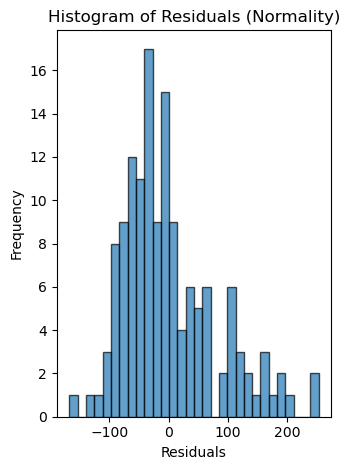

In [172]:
# גרף שני: היסטוגרמה של השאריות (בדיקת התפלגות נורמלית)
plt.subplot(1, 2, 2)
plt.hist(model_linear.resid, bins=30, edgecolor='k', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals (Normality)')

plt.tight_layout()
plt.show()

In [173]:
#הרחבה
dw = durbin_watson(model_linear.resid)
print("Durbin-Watson:", dw)

bp_test = het_breuschpagan(model_linear.resid, model_linear.model.exog)
print("Breusch-Pagan p-value:", bp_test[1])

vif_data = pd.DataFrame()
vif_data["Feature"] = X_train_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_train_const.values, i)
                   for i in range(X_train_const.shape[1])]
print(vif_data)

Durbin-Watson: 2.2110839060474503
Breusch-Pagan p-value: 0.012871938807441462
       Feature       VIF
0        const  5.935363
1  temperature  1.005760
2     humidity  1.005760


### בדיקת הנחות המודל

בוצעו בדיקות פורמליות להנחות רגרסיה לינארית:

- **אי תלות שאריות (Durbin-Watson):** הערך שהתקבל קרוב ל־2, ולכן אין עדות לאוטוקורלציה בין השאריות.
- **הומוסקדסטיות (Breusch-Pagan):** התקבלה עדות לשונות שאינה קבועה (p-value < 0.05), כלומר קיימת הטרוסקדסטיות.
- **רב-קולינאריות (VIF):** ערכי VIF קרובים ל־1, ולכן אין מתאם גבוה בין המשתנים המסבירים.

לסיכום, המודל אינו סובל מבעיית תלות בין השאריות או רב-קולינאריות, אך קיימת שונות שאינה קבועה.

# <span style="color:#1F4E79">סיכום סעיף 1 – רגרסיה לינארית פשוטה</span>

נבנה מודל רגרסיה לינארית לחיזוי **machine performance** באמצעות המשתנים  
**temperature** ו־**humidity**, ללא אינטראקציה וללא איברים פולינומיים.

---

## תוצאות המודל

המודל מסביר כ־92.3% מהשונות במשתנה התלוי  
(R² = 0.923), ולכן נחשב חזק מאוד.

שני המשתנים מובהקים סטטיסטית (p < 0.001) ובעלי השפעה חיובית.

משוואת המודל:

$$
\hat{Y} = -249.04 + 15.18 \cdot temperature + 14.71 \cdot humidity
$$

### פירוש המקדמים

- עלייה של יחידה אחת ב־temperature מעלה את machine performance בכ־15.18 יחידות, כאשר humidity קבוע.
- עלייה של יחידה אחת ב־humidity מעלה את machine performance בכ־14.71 יחידות, כאשר temperature קבוע.

---

## בדיקת הנחות המודל

### 1. גרף פיזור + קו רגרסיה
נראה קשר חיובי בין המשתנים המסבירים לבין המשתנה התלוי.  
עם זאת, הפיזור סביב הקו אינו אחיד לאורך התחום, דבר שעשוי להעיד על שונות שאינה קבועה.

### 2. גרף שאריות מול ערכים חזויים
בגרף זה נראית תבנית בצורת U ולא פיזור אקראי סביב האפס.  
תוצאה זו מצביעה על כך שהקשר אינו לינארי לחלוטין, וקיימת אפשרות שמודל פולינומי יתאים טוב יותר.

### 3. QQ Plot של השאריות
השאריות אינן נצמדות באופן מושלם לקו הישר, בעיקר בקצוות.  
סטייה זו מצביעה על חריגה מסוימת מהנחת הנורמליות.

עם זאת, במדגם בגודל 200 תצפיות, סטייה מתונה מנורמליות אינה פוגעת בחוסר ההטיה של האומדים, אך עשויה להשפיע במידה מסוימת על בדיקות המובהקות.

---

## מסקנה כללית

המודל מציג התאמה גבוהה ומקדמים מובהקים, אך בדיקות השאריות מצביעות על אפשרות של אי־לינאריות ושונות שאינה קבועה.

לפיכך, ייתכן שמודל מורכב יותר — כגון מודל עם אינטראקציה או מודל פולינומי מדרגה נמוכה — יספק התאמה טובה יותר.

# <span style="color:#1F4E79">סעיף 2 – חיזוי מול בפועל</span>

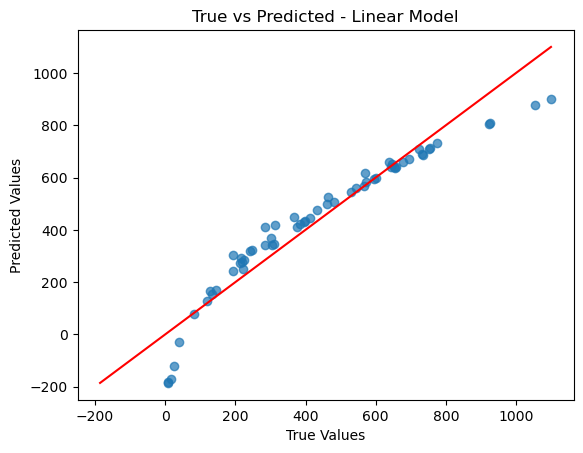

In [261]:
# חיזוי על סט הבדיקה
y_pred = model_linear.predict(sm.add_constant(X_test))

# גרף True vs Predicted
plt.scatter(y_test, y_pred, alpha=0.7)

# קו אידיאלי (y=x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted - Linear Model")
plt.show()

In [175]:
# חישוב מדדים
mse = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print("MSE:", mse)
print("R² (Test):", r2_test)

MSE: 5896.195326458229
R² (Test): 0.918051835320694



 התקבלו הערכים הבאים:

- $R^2$ על סט הבדיקה (Test set): **0.918**
- $R^2$ על כלל הנתונים (Train set): **0.923**

הסיבה להבדל הקטן בין הערכים היא ש-$R^2$ על כלל הנתונים מחושב על אותו דאטה שבו המודל אומן, ולכן המודל "מכיר" את הנתונים טוב יותר ומצליח להסביר חלק מעט גדול יותר מהשונות.

לעומת זאת, $R^2$ על סט הבדיקה מחושב על נתונים שהמודל **לא ראה במהלך האימון**. לכן זהו מדד טוב יותר ליכולת ההכללה (Generalization) של המודל לנתונים חדשים.

## סיכום סעיף 2 – השוואת ערכים אמיתיים לערכים חזויים

בגרף מוצגים הערכים האמיתיים בציר ה-X והערכים החזויים בציר ה-Y.  
הקו האדום מייצג תחזית מושלמת \( y = x \).

ניתן לראות כי רוב הנקודות ממוקמות קרוב לקו האידיאלי, דבר המעיד על רמת חיזוי גבוהה של המודל גם על סט הבדיקה.

מדדי הביצוע שהתקבלו:

- **MSE = 5896.20**
- **R² (Test) = 0.918**

כלומר, המודל מסביר כ-91.8% מהשונות בנתוני הבדיקה, תוצאה המעידה על יכולת הכללה טובה ולא רק על התאמה לנתוני האימון.

עם זאת, ניתן להבחין כי בערכים הגבוהים קיימת סטייה מסוימת מהקו האידיאלי, כלומר המודל נוטה להמעיט מעט את הערכים הגבוהים של *machine performance*.

בסך הכול, המודל הלינארי מציג ביצועי חיזוי טובים מאוד. עם זאת, לאור התבנית שנצפתה בשאריות בסעיף הקודם, ייתכן שמודל מורכב יותר — כגון מודל הכולל אינטראקציה או רכיב לא לינארי — יספק התאמה טובה אף יותר.

# <span style="color:#1F4E79">סעיף 3 - מודל לינארי עם אינטראקציה</span>

In [195]:
#  יצירת משתנה אינטראקציה

X_train_inter = X_train.copy()
X_test_inter = X_test.copy()

X_train_inter["interaction"] = (
    X_train_inter["temperature"] * X_train_inter["humidity"]
)

X_test_inter["interaction"] = (
    X_test_inter["temperature"] * X_test_inter["humidity"]
)

In [196]:
#  הוספת קבוע ואימון המודל

X_train_inter_const = sm.add_constant(X_train_inter)
model_inter = sm.OLS(y_train, X_train_inter_const).fit()

print(model_inter.summary())

                             OLS Regression Results                            
Dep. Variable:     machine performance   R-squared:                       0.992
Model:                             OLS   Adj. R-squared:                  0.991
Method:                  Least Squares   F-statistic:                     5393.
Date:                 Wed, 04 Mar 2026   Prob (F-statistic):          3.92e-141
Time:                         18:09:10   Log-Likelihood:                -654.99
No. Observations:                  140   AIC:                             1318.
Df Residuals:                      136   BIC:                             1330.
Df Model:                            3                                         
Covariance Type:             nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         -69.4509      7.631     -9

### Equation – Linear Model with Interaction

$$
\hat{Y} = -69.45 + 4.30 \cdot temperature + 7.63 \cdot humidity + 0.4446 \cdot (temperature \times humidity)
$$

where:

\( Y = \) machine performance  

The model includes an interaction term, meaning that the effect of humidity on machine performance depends on the level of temperature (and vice versa).

In [197]:
#  חיזוי על סט הבדיקה

X_test_inter_const = sm.add_constant(X_test_inter)

y_pred_inter = model_inter.predict(X_test_inter_const)

In [198]:
# מדדי ביצוע על Test

mse_inter = mean_squared_error(y_test, y_pred_inter)
r2_inter = r2_score(y_test, y_pred_inter)

print("MSE (interaction):", mse_inter)
print("R² (interaction):", r2_inter)

MSE (interaction): 794.4568456599546
R² (interaction): 0.9889582558219198


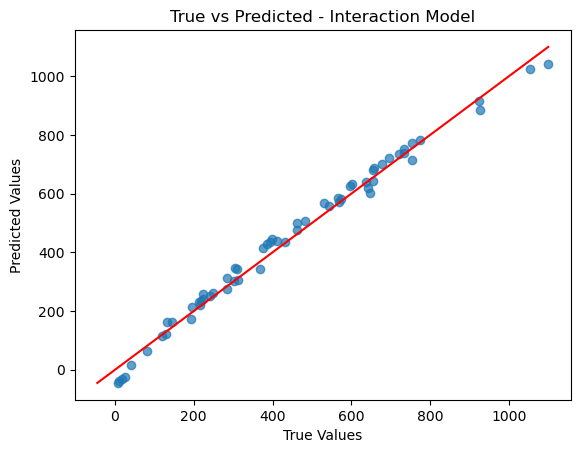

In [199]:
# גרף True vs Predicted

plt.figure()
plt.scatter(y_test, y_pred_inter, alpha=0.7)

min_val = min(y_test.min(), y_pred_inter.min())
max_val = max(y_test.max(), y_pred_inter.max())

plt.plot([min_val, max_val],
         [min_val, max_val],
         color='red')

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted - Interaction Model")
plt.show()

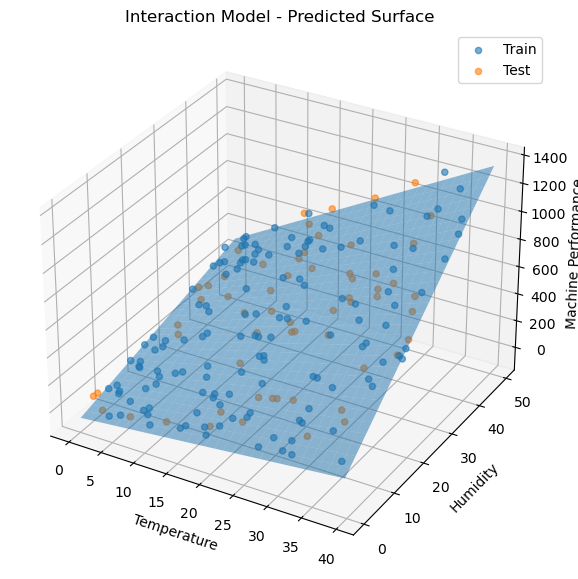

In [200]:
# יצירת grid לחיזוי משטח

temp_min, temp_max = X["temperature"].min(), X["temperature"].max()
hum_min, hum_max = X["humidity"].min(), X["humidity"].max()

temp_grid = np.linspace(temp_min, temp_max, 30)
hum_grid = np.linspace(hum_min, hum_max, 30)

T, H = np.meshgrid(temp_grid, hum_grid)

grid_df = pd.DataFrame({
    "temperature": T.ravel(),
    "humidity": H.ravel()
})

grid_df["interaction"] = (
    grid_df["temperature"] * grid_df["humidity"]
)

Z = model_inter.predict(
    sm.add_constant(grid_df, has_constant="add")
).values

Z = Z.reshape(T.shape)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(T, H, Z, alpha=0.5)

ax.scatter(X_train["temperature"],
           X_train["humidity"],
           y_train,
           alpha=0.6,
           label="Train")

ax.scatter(X_test["temperature"],
           X_test["humidity"],
           y_test,
           alpha=0.6,
           label="Test")

ax.set_title("Interaction Model - Predicted Surface")
ax.set_xlabel("Temperature")
ax.set_ylabel("Humidity")
ax.set_zlabel("Machine Performance")
ax.legend()

plt.show()

## סיכום סעיף 3 – מודל לינארי עם אינטראקציה

נבנה מודל רגרסיה לינארית הכולל איבר אינטראקציה בין  
**temperature** לבין **humidity**, במטרה לבדוק האם השפעת אחד המשתנים תלויה בערך המשתנה השני.

משוואת המודל:

$$
\hat{Y} = -69.45 + 4.30 \cdot temperature + 7.63 \cdot humidity + 0.4446 \cdot (temperature \times humidity)
$$

מקדם האינטראקציה מובהק סטטיסטית (p < 0.001), ולכן ניתן להסיק כי קיים אפקט משולב בין שני המשתנים.

---

### ביצועי המודל על סט הבדיקה

|  (Test) מדד | ללא אינטראקציה | עם אינטראקציה |
|------|----------------|----------------|
| R² | 0.918 | 0.992 |
| MSE | 5896 | 794 |

הוספת איבר האינטראקציה משפרת באופן משמעותי את יכולת ההסבר והחיזוי של המודל.

המודל עם האינטראקציה מסביר כ-99.2% מהשונות בנתוני הבדיקה ומציג ירידה חדה בשגיאת החיזוי.

---

## מסקנה

הקשר בין temperature ל-humidity אינו אדיטיבי בלבד, אלא משולב.  
לפיכך, מודל הכולל אינטראקציה מתאים לנתונים טוב יותר ממודל לינארי פשוט.

# <span style="color:#1F4E79">סעיף 4 – השפעת העלאת הלחות במודל עם אינטראקציה</span>

In [69]:
# חישוב ההשפעה של humidity כאשר temperature = 10

beta_h = model_inter.params['humidity']
beta_int = model_inter.params['interaction']
T = 10

effect_humidity = beta_h + beta_int * T
effect_humidity

12.072139553206107

## סיכום סעיף 4 – פירוש השפעת לחות כאשר טמפרטורה = 10

במודל עם אינטראקציה:

$$
\hat{Y} = -69.45 + 4.30T + 7.63H + 0.4446(T \cdot H)
$$

במודל הכולל אינטראקציה, ההשפעה של $H$ על $Y$ אינה קבועה, אלא תלויה בערך $T$.

השינוי בביצועי המכונה כאשר מעלים את $H$ ביחידה אחת מחושב כך:

$$
\frac{\partial Y}{\partial H} = \beta_H + \beta_{TH} \cdot T
$$

נציב $T = 10$:

$$
\frac{\partial Y}{\partial H} = 7.63 + 0.4446 \cdot 10
$$

$$
= 7.63 + 4.446
$$

$$
= 12.07
$$

מסקנה: כאשר הטמפרטורה שווה ל־10, עלייה של יחידה אחת בלחות מעלה את ביצועי המכונה בכ־12.07 יחידות.

תוצאה זו נובעת ממקדם האינטראקציה החיובי והמובהק סטטיסטית, המצביע על כך שככל שהטמפרטורה גבוהה יותר, כך גדלה השפעת הלחות על ביצועי המכונה.

כלומר, השפעת הלחות אינה קבועה אלא משתנה בהתאם לרמת הטמפרטורה.


# <span style="color:#1F4E79">סעיף 5 – רגרסיה פולינומית ובחירת המודל הטוב ביותר</span>

In [227]:
# עזר: הדגשות בטבלה

def highlight_top2(s):
    top2 = s.nlargest(2).values
    return ['color: red; font-weight: bold' if v in top2 else '' for v in s]

def highlight_min(s):
    return ['color: red; font-weight: bold' if v == s.min() else '' for v in s]


def highlight_max(s):
    return ['color: red; font-weight: bold' if v == s.max() else '' for v in s]

In [228]:
# 1) השוואת דרגות פולינום (1-5)
#    לפי AIC/BIC + Adj R^2

results = []
models = {}

for degree in range(1, 6):
    poly = PolynomialFeatures(degree=degree, include_bias=False)

    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    X_train_poly_const = sm.add_constant(X_train_poly, has_constant='add')
    X_test_poly_const = sm.add_constant(X_test_poly, has_constant='add')

    model = sm.OLS(y_train, X_train_poly_const).fit()
    y_pred_test = model.predict(X_test_poly_const)

    results.append({
        "Degree": degree,
        "AIC": model.aic,
        "BIC": model.bic,
        "Adjusted R^2 (Train)": model.rsquared_adj,
        "MSE (Test)": mean_squared_error(y_test, y_pred_test),
        "R^2 (Test)": r2_score(y_test, y_pred_test)
    })

    models[degree] = {
        "model": model,
        "poly": poly,
        "y_pred_test": y_pred_test
    }

results_df = pd.DataFrame(results).round(4)

styled_df = (
    results_df.style
    .apply(highlight_top2, subset=["Adjusted R^2 (Train)"])
    .apply(highlight_min, subset=["AIC", "BIC", "MSE (Test)"])
)
styled_df

,Degree,AIC,BIC,Adjusted R^2 (Train),MSE (Test),R^2 (Test)
0,1,1627.890300,1636.715300,0.921500,5896.195300,0.918100
1,2,703.060200,720.710000,0.999900,8.116300,0.999900
2,3,706.304300,735.720700,0.999900,8.617300,0.999900
3,4,712.248500,756.373100,0.999900,8.923200,0.999900
4,5,719.372500,781.147000,0.999900,9.333100,0.999900


## מסקנות מהשוואת דרגות הפולינום

מהטבלה עולה כי המעבר ממודל לינארי (Degree = 1) למודל פולינומי מדרגה 2 מוביל לשיפור משמעותי בביצועי המודל.  
ניתן לראות ירידה חדה בערך ה-MSE ועלייה בערך \(R^2\) על סט הבדיקה, דבר המעיד על יכולת חיזוי טובה יותר.

עם זאת, הגדלת דרגת הפולינום מעבר ל-2 אינה מובילה לשיפור נוסף בביצועים.  
מדדי המידע AIC ו-BIC אף עולים עבור דרגות גבוהות יותר, דבר המעיד על עלייה במורכבות המודל ללא תרומה ממשית לדיוק החיזוי.

תופעה זו מצביעה על כך שמודלים פולינומיים בדרגות גבוהות יותר עלולים להוביל להתאמת יתר (Overfitting), כלומר התאמה טובה לנתוני האימון אך ללא שיפור ביכולת ההכללה.

לפיכך, המודל הפולינומי מדרגה 2 נבחר כמודל המועדף, שכן הוא מספק איזון מיטבי בין דיוק החיזוי לבין מורכבות המודל.

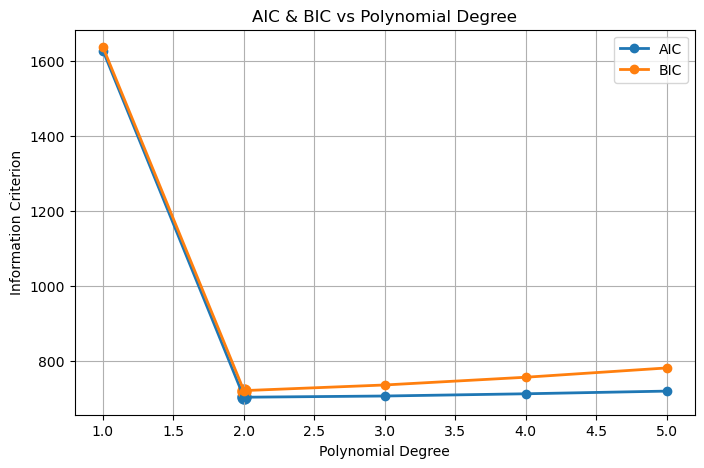

In [229]:
# 2) גרף AIC & BIC

plt.figure(figsize=(8,5))
plt.plot(results_df["Degree"], results_df["AIC"], marker="o", linewidth=2, label="AIC")
plt.plot(results_df["Degree"], results_df["BIC"], marker="o", linewidth=2, label="BIC")

# סימון מינימום
min_aic_idx = results_df["AIC"].idxmin()
min_bic_idx = results_df["BIC"].idxmin()

plt.scatter(results_df.loc[min_aic_idx, "Degree"], results_df.loc[min_aic_idx, "AIC"], s=90)
plt.scatter(results_df.loc[min_bic_idx, "Degree"], results_df.loc[min_bic_idx, "BIC"], s=90)

plt.xlabel("Polynomial Degree")
plt.ylabel("Information Criterion")
plt.title("AIC & BIC vs Polynomial Degree")
plt.grid(True)
plt.legend()
plt.show()

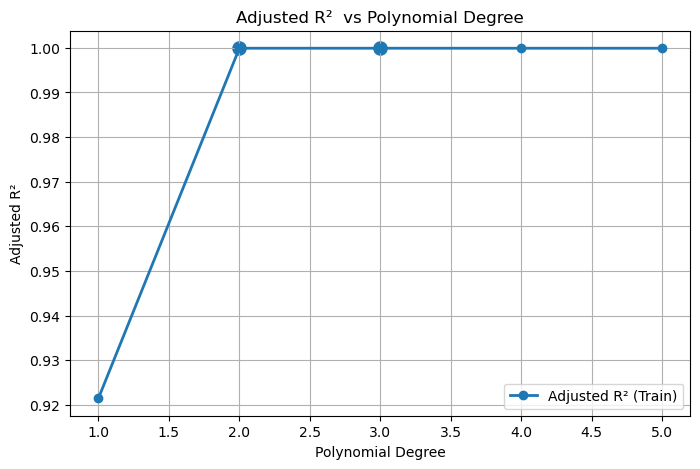

In [238]:
# 3) גרף Adjusted R² (Train)

plt.figure(figsize=(8,5))
plt.plot(results_df["Degree"], results_df["Adjusted R^2 (Train)"], marker="o", linewidth=2, label="Adjusted R² (Train)")

top2_idx = results_df["Adjusted R^2 (Train)"].nlargest(2).index
plt.scatter(results_df.loc[top2_idx, "Degree"], results_df.loc[top2_idx, "Adjusted R^2 (Train)"], s=90)

plt.xlabel("Polynomial Degree")
plt.ylabel("Adjusted R²")
plt.title("Adjusted R²  vs Polynomial Degree")
plt.grid(True)
plt.legend()
plt.show()

In [231]:
# 4) בחירת דרגה אופטימלית

best_degree = int(results_df.sort_values("BIC").iloc[0]["Degree"])
print("Best degree by BIC:", best_degree)

best_model = models[best_degree]["model"]
best_poly = models[best_degree]["poly"]

Best degree by BIC: 2


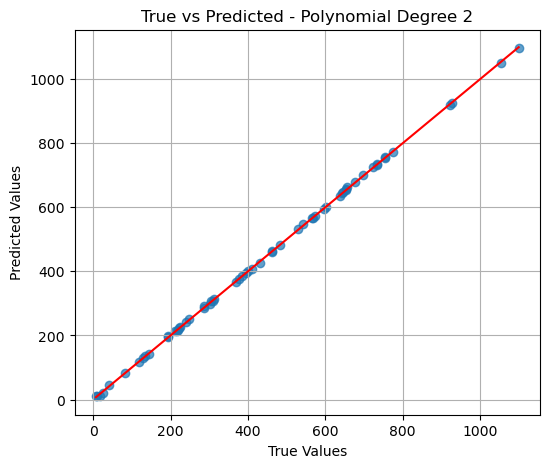

MSE (Test): 8.116331886008346
R² (Test): 0.9998871953072854
                             OLS Regression Results                            
Dep. Variable:     machine performance   R-squared:                       1.000
Model:                             OLS   Adj. R-squared:                  1.000
Method:                  Least Squares   F-statistic:                 2.674e+05
Date:                 Wed, 04 Mar 2026   Prob (F-statistic):          4.94e-266
Time:                         20:18:26   Log-Likelihood:                -345.53
No. Observations:                  140   AIC:                             703.1
Df Residuals:                      134   BIC:                             720.7
Df Model:                            5                                         
Covariance Type:             nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------

In [232]:
# 5) True vs Predicted (Test) עבור המודל הנבחר

y_pred_best = models[best_degree]["y_pred_test"]

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred_best, alpha=0.7)

min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red")

plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title(f"True vs Predicted - Polynomial Degree {best_degree}")
plt.grid(True)
plt.show()

print("MSE (Test):", mean_squared_error(y_test, y_pred_best))
print("R² (Test):", r2_score(y_test, y_pred_best))

print(best_model.summary())

### Equation – Polynomial Regression Model (Degree 2)

$$
\hat{Y} = 4.99 
+ 0.9379 \cdot temperature 
+ 0.5269 \cdot humidity 
+ 0.0817 \cdot temperature^2 
+ 0.4624 \cdot (temperature \times humidity) 
+ 0.1387 \cdot humidity^2
$$

where:

\( Y \) = machine performance  

The model includes quadratic terms and an interaction term.  
This implies a non-linear relationship between the predictors and machine performance.  

The quadratic terms introduce curvature into the response surface, while the interaction term allows the effect of temperature to depend on humidity (and vice versa).

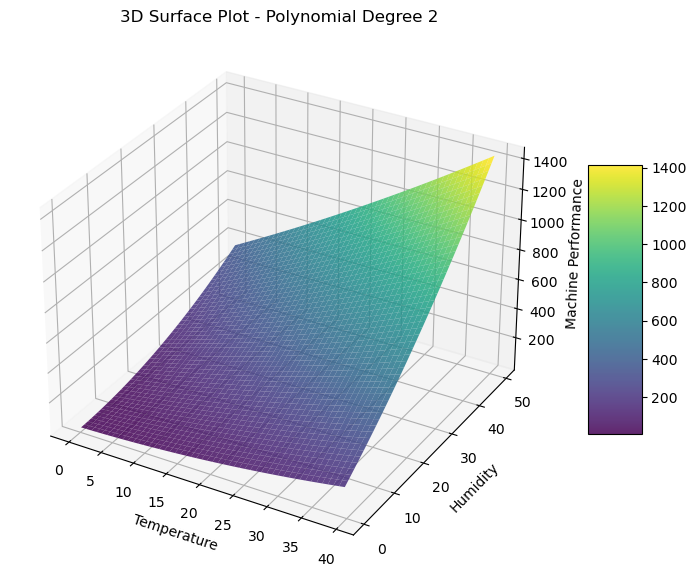

In [233]:
# לבנות מחדש פולינום דרגה 2

poly2 = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly2 = poly2.fit_transform(X_train)
X_test_poly2 = poly2.transform(X_test)

model_poly2 = LinearRegression()
model_poly2.fit(X_train_poly2, y_train)

#  יצירת גריד

temp_range = np.linspace(X['temperature'].min(), X['temperature'].max(), 50)
hum_range = np.linspace(X['humidity'].min(), X['humidity'].max(), 50)

T_grid, H_grid = np.meshgrid(temp_range, hum_range)

grid_df = pd.DataFrame({
    'temperature': T_grid.ravel(),
    'humidity': H_grid.ravel()
})

#  טרנספורמציה וחיזוי

grid_poly2 = poly2.transform(grid_df)
Z_pred = model_poly2.predict(grid_poly2)

Z_grid = Z_pred.reshape(T_grid.shape)

#  ציור תלת-ממדי

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surface = ax.plot_surface(
    T_grid,
    H_grid,
    Z_grid,
    cmap='viridis',
    alpha=0.85
)

ax.set_xlabel("Temperature")
ax.set_ylabel("Humidity")
ax.set_zlabel("Machine Performance")
ax.set_title("3D Surface Plot - Polynomial Degree 2")

fig.colorbar(surface, shrink=0.5, aspect=5)

plt.show()

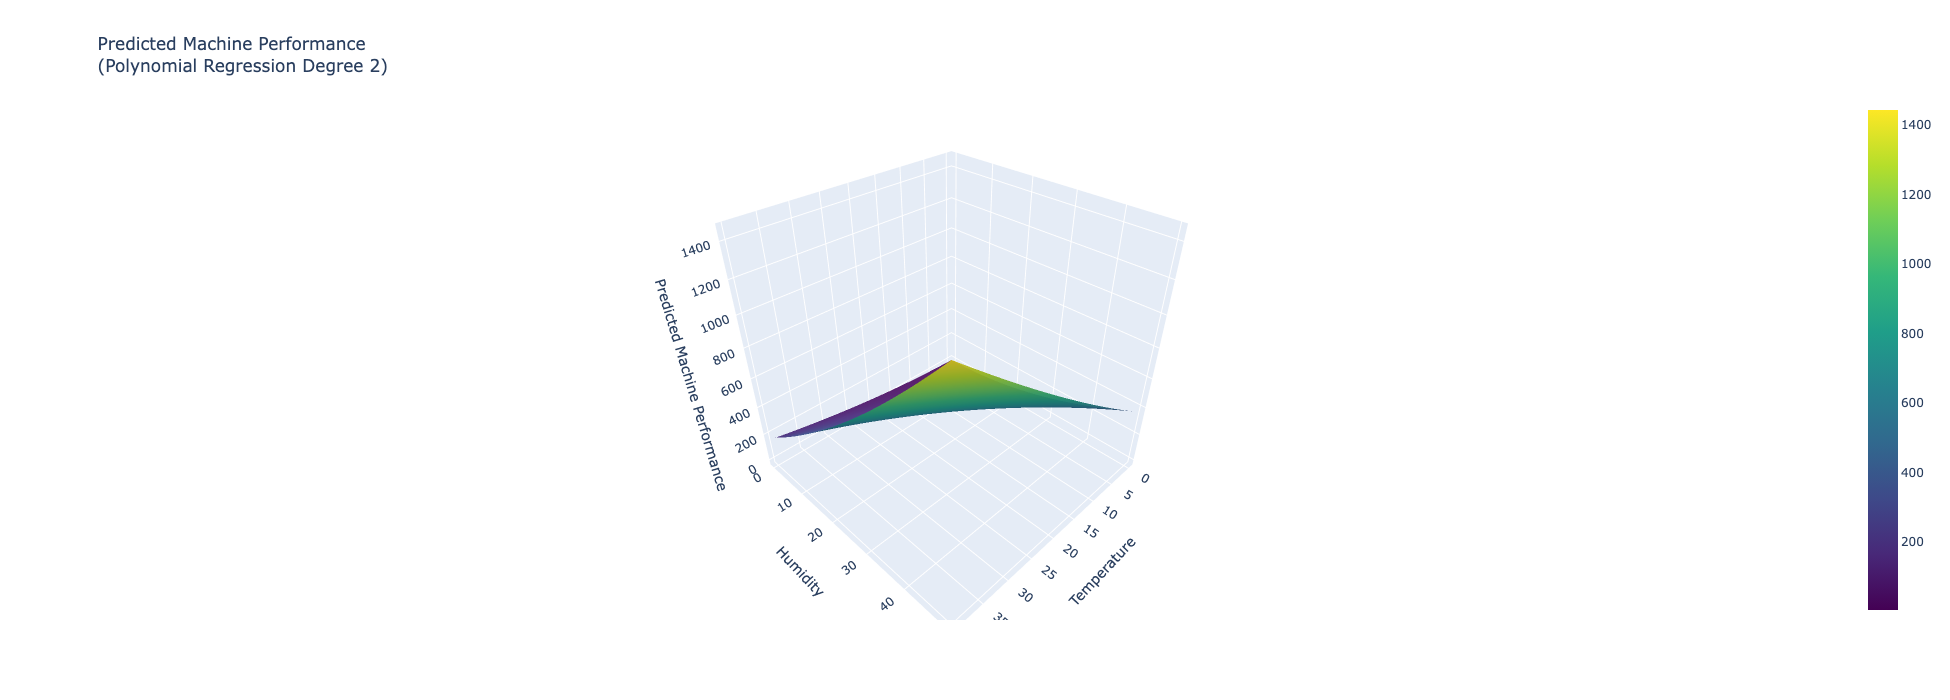

In [264]:
# יצירת גרף אינטראקטיבי
fig = go.Figure(
    data=[
        go.Surface(
            x=T_grid,
            y=H_grid,
            z=Z_grid,
            colorscale="Viridis",
            opacity=0.95
        )
    ]
)

fig.update_layout(
    title="Predicted Machine Performance<br>(Polynomial Regression Degree 2)",
    scene=dict(
        xaxis_title="Temperature",
        yaxis_title="Humidity",
        zaxis_title="Predicted Machine Performance"
    ),
    width=950,
    height=700
)

fig.show()

## סיכום – בחירת המודל הפולינומי האופטימלי

במסגרת הסעיף נבחנה התאמה של מודלים פולינומיים בדרגות שונות $d \in \{1,\dots,5\}$ לצורך חיזוי **machine performance** על בסיס המשתנים **temperature** ו-**humidity**.

לכל דרגה בוצעו השלבים הבאים:

1. יצירת פיצ'רים פולינומיים באמצעות `PolynomialFeatures`
2. אימון מודל OLS על סט האימון (Train)
3. חיזוי על סט הבדיקה (Test)
4. חישוב מדדי הערכה להשוואת המודלים

המודלים הושוו באמצעות שני סוגי מדדים:

**מדדי התאמה (Train)**  
- Adjusted \(R^2\)  
- AIC / BIC  

**מדדי חיזוי (Test)**  
- MSE (Test)  
- R^2 (Test)

מהתוצאות עולה כי:

- המעבר ממודל לינארי (דרגה 1) למודל פולינומי מדרגה 2 משפר משמעותית את ביצועי המודל.
- בדרגות גבוהות יותר השיפור ב-Adjusted \(R^2\) זניח.
- מדדי AIC ו-BIC מתחילים לעלות לאחר דרגה 2, דבר המעיד כי המורכבות גדלה ללא שיפור אמיתי באיכות המודל.

לכן הדרגה שנבחרה כמודל הפולינומי האופטימלי היא **דרגה 2**, שכן היא מספקת את השילוב הטוב ביותר בין:

- איכות התאמה גבוהה
- יכולת חיזוי טובה על נתונים חדשים
- מורכבות מודל סבירה

In [259]:
# תיקון שם העמודה
df = df.rename(columns={"machine performance": "machine_performance"})

# רשימת תוצאות
results = []

#  מודל לינארי
model_linear = smf.ols(
    "machine_performance ~ temperature + humidity",
    data=df
).fit()

y_pred_linear = model_linear.predict(X_test)

results.append([
    "Linear",
    model_linear.rsquared,
    model_linear.rsquared_adj,
    model_linear.aic,
    model_linear.bic,
    mean_squared_error(y_test, y_pred_linear),
    r2_score(y_test, y_pred_linear)
])

#  מודל אינטראקציה
model_interaction = smf.ols(
    "machine_performance ~ temperature * humidity",
    data=df
).fit()

y_pred_interaction = model_interaction.predict(X_test)

results.append([
    "Interaction",
    model_interaction.rsquared,
    model_interaction.rsquared_adj,
    model_interaction.aic,
    model_interaction.bic,
    mean_squared_error(y_test, y_pred_interaction),
    r2_score(y_test, y_pred_interaction)
])

#  מודל פולינומי דרגה 2
# sklearn משמש לחיזוי
# statsmodels משמש לחישוב AIC/BIC

poly = PolynomialFeatures(degree=2, include_bias=False)

X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)

y_pred_poly = model_poly.predict(X_test_poly)

# statsmodels לצורך AIC/BIC
X_train_poly_sm = sm.add_constant(X_train_poly)
model_poly_sm = sm.OLS(y_train, X_train_poly_sm).fit()

results.append([
    "Polynomial (deg 2)",
    model_poly_sm.rsquared,
    model_poly_sm.rsquared_adj,
    model_poly_sm.aic,
    model_poly_sm.bic,
    mean_squared_error(y_test, y_pred_poly),
    r2_score(y_test, y_pred_poly)
])

# יצירת טבלת השוואה
comparison_df = pd.DataFrame(results, columns=[
    "Model",
    "R²",
    "Adj R²",
    "AIC",
    "BIC",
    "MSE (Test)",
    "R² (Test)"
])


styled_df = (
    comparison_df.style
    .apply(highlight_max, subset=["Adj R²", "R² (Test)"])
    .apply(highlight_min, subset=["AIC", "BIC", "MSE (Test)"])
    .format(precision=4)
)

styled_df

,Model,R²,Adj R²,AIC,BIC,MSE (Test),R² (Test)
0,Linear,0.9228,0.9220,2318.9428,2328.8377,5854.7418,0.9186
1,Interaction,0.9912,0.9911,1886.7719,1899.9652,740.7753,0.9897
2,Polynomial (deg 2),0.9999,0.9999,703.0602,720.7100,8.1163,0.9999


## סיכום סעיף 5 - השוואת מודלים

לאחר בחירת המודל הפולינומי האופטימלי (דרגה 2), בוצעה השוואה בין שלושה סוגי מודלים:

1. רגרסיה לינארית פשוטה  
2. רגרסיה עם אינטראקציה  
3. רגרסיה פולינומית מדרגה 2  

ההשוואה בוצעה באמצעות מדדי התאמה ומדדי חיזוי.

### מדדי התאמה
- \(R^2\)
- Adjusted \(R^2\)
- AIC
- BIC

### מדדי חיזוי
- MSE (Test)
- \(R^2\) (Test)

מההשוואה עולה כי המודל הפולינומי מדרגה 2 מציג את הביצועים הטובים ביותר.

בהשוואה למודלים הפשוטים יותר נמצא כי:

- ערך \(R^2\) גבוה יותר, כלומר המודל מסביר חלק גדול יותר מהשונות בנתונים.
- ערך ה-MSE על סט הבדיקה נמוך יותר, מה שמעיד על חיזוי מדויק יותר.
- ערכי AIC ו-BIC נמוכים יותר, דבר המעיד על מודל בעל איזון טוב בין איכות התאמה לבין מורכבות.

לעומת זאת, המודל הלינארי הפשוט והמודל עם האינטראקציה מצליחים להסביר חלק מהקשר בין המשתנים, אך אינם מצליחים ללכוד את האופי הלא-לינארי של הקשר בין הטמפרטורה, הלחות וביצועי המכונה.

### מסקנה סופית

המודל הפולינומי מדרגה 2 מספק את הביצועים הטובים ביותר מבין המודלים שנבחנו.

מודל זה מצליח לתאר את הקשר הלא-לינארי בין המשתנים בצורה מדויקת יותר, תוך שמירה על רמת מורכבות סבירה ויכולת הכללה טובה לנתונים חדשים.

לפיכך, מודל זה נבחר כמודל הסופי לחיזוי **machine performance**.

# <span style="color:#1f4e79">סעיף 6 – בחינת השפעת המשתנים על ביצוע המכונה</span>

במטרה לזהות איזה משתנה משפיע ביותר על ביצוע המכונה, נבחנה ההשפעה השולית (Marginal Effect) של כל משתנה במודל שנבחר.

בסעיף הקודם נמצא כי המודל הפולינומי מדרגה 2 מספק את הביצועים הטובים ביותר, ולכן הוא נבחר כמודל הסופי לניתוח.

המודל הפולינומי הוא:

$$
\hat{Y} =
\beta_0
+
\beta_1 T
+
\beta_2 H
+
\beta_3 T^2
+
\beta_4 H^2
+
\beta_5 (T \cdot H)
$$

במודל מסוג זה ההשפעה של כל משתנה אינה קבועה, אלא תלויה בערכים של המשתנים עצמם, בגלל קיום איברים ריבועיים ואינטראקציה.

לכן חושבה ההשפעה השולית בנקודת ייחוס – ממוצעי המשתנים בסט האימון.

### ההשפעה השולית של טמפרטורה

$$
\frac{\partial Y}{\partial T}
=
\beta_1
+
2\beta_3 T
+
\beta_5 H
$$

### ההשפעה השולית של לחות

$$
\frac{\partial Y}{\partial H}
=
\beta_2
+
2\beta_4 H
+
\beta_5 T
$$

---

## השוואת עוצמת ההשפעה

מאחר שלמשתנים סקלות שונות, בוצעה גם השוואה באמצעות שינוי של סטיית תקן אחת בכל משתנה.

כלומר נבדק:

- כמה משתנה ביצוע המכונה כאשר מעלים את הטמפרטורה ב־1 סטיית תקן
- כמה משתנה ביצוע המכונה כאשר מעלים את הלחות ב־1 סטיית תקן

גישה זו מאפשרת השוואה הוגנת בין משתנים בעלי יחידות מדידה שונות.

בחירה זו מקובלת בניתוח מודלים לא-לינאריים, שכן ההשפעה השולית תלויה בערכי המשתנים ולכן נהוג להעריך אותה בנקודת ייחוס מייצגת.


In [247]:
# מקדמים של המודל הפולינומי
params = model_poly_sm.params

beta0 = params[0]
beta_T = params[1]
beta_H = params[2]
beta_T2 = params[3]
beta_TH = params[4]
beta_H2 = params[5]

# ממוצעי המשתנים
T_mean = df['temperature'].mean()
H_mean = df['humidity'].mean()

# נגזרות שוליות לפי המודל הפולינומי
dY_dT = beta_T + 2*beta_T2*T_mean + beta_TH*H_mean
dY_dH = beta_H + 2*beta_H2*H_mean + beta_TH*T_mean

# סטיות תקן
T_sd = df['temperature'].std()
H_sd = df['humidity'].std()

# השפעה של שינוי של סטיית תקן אחת
Effect_T = dY_dT * T_sd
Effect_H = dY_dH * H_sd

print("Effect of +1 SD Temperature:", Effect_T)
print("Effect of +1 SD Humidity:", Effect_H)

if Effect_H > Effect_T:
    print("Humidity has the larger impact.")
else:
    print("Temperature has the larger impact.")

Effect of +1 SD Temperature: 180.04045421168288
Effect of +1 SD Humidity: 228.53072742191554
Humidity has the larger impact.


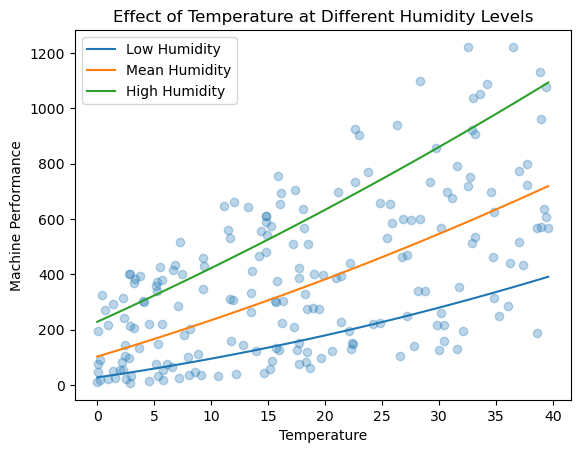

In [248]:
# מקדמים מהמודל הפולינומי
params = model_poly_sm.params

b0 = params[0]
bT = params[1]
bH = params[2]
bT2 = params[3]
bTH = params[4]
bH2 = params[5]

# טווח טמפרטורות
T_range = np.linspace(df['temperature'].min(), df['temperature'].max(), 100)

# שלוש רמות לחות
H_low = df['humidity'].quantile(0.25)
H_mid = df['humidity'].mean()
H_high = df['humidity'].quantile(0.75)

# חיזוי
Y_low = b0 + bT*T_range + bH*H_low + bT2*T_range**2 + bTH*T_range*H_low + bH2*H_low**2
Y_mid = b0 + bT*T_range + bH*H_mid + bT2*T_range**2 + bTH*T_range*H_mid + bH2*H_mid**2
Y_high = b0 + bT*T_range + bH*H_high + bT2*T_range**2 + bTH*T_range*H_high + bH2*H_high**2

plt.figure()

plt.scatter(df['temperature'], df['machine_performance'], alpha=0.3)

plt.plot(T_range, Y_low, label="Low Humidity")
plt.plot(T_range, Y_mid, label="Mean Humidity")
plt.plot(T_range, Y_high, label="High Humidity")

plt.xlabel("Temperature")
plt.ylabel("Machine Performance")
plt.title("Effect of Temperature at Different Humidity Levels")
plt.legend()
plt.show()

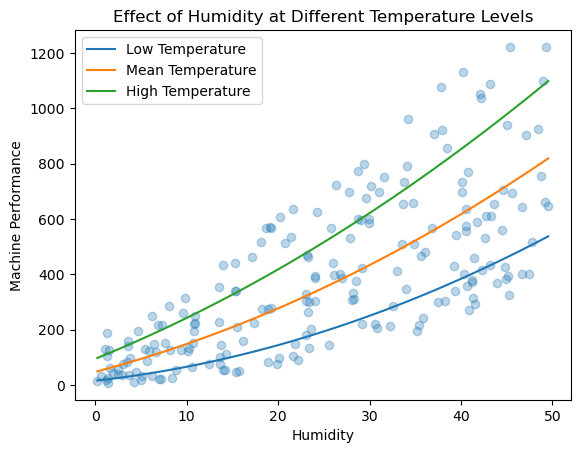

In [249]:
H_range = np.linspace(df['humidity'].min(), df['humidity'].max(), 100)

T_low = df['temperature'].quantile(0.25)
T_mid = df['temperature'].mean()
T_high = df['temperature'].quantile(0.75)

Y_lowT = b0 + bT*T_low + bH*H_range + bT2*T_low**2 + bTH*T_low*H_range + bH2*H_range**2
Y_midT = b0 + bT*T_mid + bH*H_range + bT2*T_mid**2 + bTH*T_mid*H_range + bH2*H_range**2
Y_highT = b0 + bT*T_high + bH*H_range + bT2*T_high**2 + bTH*T_high*H_range + bH2*H_range**2

plt.figure()

plt.scatter(df['humidity'], df['machine_performance'], alpha=0.3)

plt.plot(H_range, Y_lowT, label="Low Temperature")
plt.plot(H_range, Y_midT, label="Mean Temperature")
plt.plot(H_range, Y_highT, label="High Temperature")

plt.xlabel("Humidity")
plt.ylabel("Machine Performance")
plt.title("Effect of Humidity at Different Temperature Levels")
plt.legend()
plt.show()

הגרפים מציגים את הקשר בין כל אחד מהמשתנים המסבירים לבין ביצוע המכונה עבור רמות שונות של המשתנה השני.

ניתן לראות כי הקווים אינם מקבילים, כלומר השיפוע של הקשר בין המשתנים משתנה בהתאם לערך המשתנה השני. תוצאה זו מעידה על קיומה של אינטראקציה בין הטמפרטורה ללחות: ההשפעה של כל אחד מהמשתנים על ביצוע המכונה תלויה בערכו של המשתנה האחר.

ממצא זה תואם את מבנה המודל הפולינומי שנבחר, הכולל איבר אינטראקציה בין המשתנים.

## סיכום סעיף 6 - השוואת עוצמת ההשפעה בין המשתנים

במודל הפולינומי שנבחר, ההשפעה של כל משתנה על ביצוע המכונה אינה קבועה אלא תלויה בערכי המשתנים עצמם, בשל קיומם של איברים ריבועיים ואינטראקציה.

לכן נבחנה ההשפעה השולית (Marginal Effect) של כל משתנה, המחושבת באמצעות הנגזרת של פונקציית החיזוי ביחס למשתנה הרלוונטי.

השפעת הטמפרטורה:

$$
\frac{\partial Y}{\partial T}
=
\beta_1 + 2\beta_3T + \beta_5H
$$

השפעת הלחות:

$$
\frac{\partial Y}{\partial H}
=
\beta_2 + 2\beta_4H + \beta_5T
$$

החישוב בוצע בנקודת הממוצעים של המשתנים, על מנת לקבל הערכה מייצגת של ההשפעה במערכת.

מאחר שהמשתנים נמדדים בסקלות שונות, בוצעה גם השוואה מתוקננת באמצעות שינוי של סטיית תקן אחת בכל משתנה.

כלומר חושבה ההשפעה של שינוי טיפוסי בכל משתנה:

$$
Effect = MarginalEffect \times SD
$$

התקבלו התוצאות הבאות:

- השפעה של +1 סטיית תקן בטמפרטורה: **180.04**
- השפעה של +1 סטיית תקן בלחות: **228.53**

---

### מסקנה

מאחר שההשפעה המתוקננת של הלחות גבוהה יותר:

$$
228.53 > 180.04
$$

ניתן להסיק כי **הלחות היא המשתנה בעל ההשפעה הגדולה ביותר על ביצוע המכונה במודל שנבחר**.

המסקנה מבוססת על השוואת השפעות שוליות מתוקננות, המאפשרת השוואה הוגנת בין משתנים בעלי יחידות מדידה שונות.

# <span style="color:#1f4e79"> סעיף 7 – ניתוח שגיאת האימון כפונקציה של דרגת הפולינום
</span>

In [254]:
degrees = range(1,6)
mse_train = []

for deg in degrees:
    
    poly = PolynomialFeatures(degree=deg, include_bias=False)
    
    X_train_poly = poly.fit_transform(X_train)
    
    model = LinearRegression()
    model.fit(X_train_poly, y_train)
    
    y_train_pred = model.predict(X_train_poly)
    
    mse = mean_squared_error(y_train, y_train_pred)
    mse_train.append(mse)
    
# יצירת טבלה
train_mse_table = pd.DataFrame({
    "Polynomial Degree": degrees,
    "MSE (Train)": mse_train
})
train_mse_table.round(4)

,Polynomial Degree,MSE (Train)
0,1,6292.1236
1,2,8.1520
2,3,7.8798
3,4,7.6547
4,5,7.3927


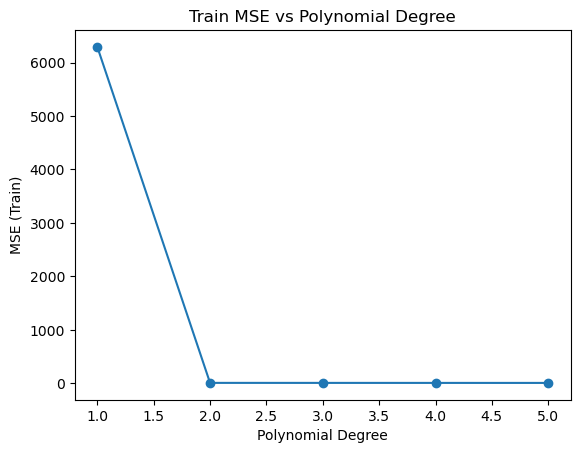

In [255]:
# גרף
plt.figure()
plt.plot(degrees, mse_train, marker='o')
plt.xlabel("Polynomial Degree")
plt.ylabel("MSE (Train)")
plt.title("Train MSE vs Polynomial Degree")
plt.show()

# MSE סיכום סעיף 7 - על סט האימון כפונקציה של דרגת הפולינום

התקבלו התוצאות הבאות עבור שגיאת האימון (MSE על סט ה-Train):

| Degree | MSE (Train) |
|--------|-------------|
| 1 | 6292.12 |
| 2 | 8.15 |
| 3 | 7.88 |
| 4 | 7.65 |
| 5 | 7.39 |

---

## ניתוח אמפירי של התוצאות

### ירידה חדה מדרגה 1 ל־2

במעבר ממודל לינארי פשוט (דרגה 1) למודל פולינומי מדרגה 2 חלה ירידה דרמטית בשגיאת האימון.

ממצא זה מצביע על כך שהקשר בין המשתנים המסבירים לבין ביצוע המכונה אינו לינארי בלבד, וכי קיימים רכיבים לא־לינאריים משמעותיים בנתונים (כגון איברי ריבוע ואינטראקציה).  
המודל הלינארי הבסיסי אינו מצליח ללכוד את מבנה הנתונים המלא ולכן מתקבלת שגיאה גבוהה במיוחד.

---

### ירידה מתונה בדרגות גבוהות יותר

הגרף מציג באופן ויזואלי את הירידה המונוטונית בשגיאת האימון ככל שדרגת הפולינום עולה.  
עם זאת, במעבר מדרגה 2 לדרגות 3–5 נצפית ירידה קטנה בלבד ב-MSE.

משמעות הדבר היא:

- דרגה 2 כבר לוכדת כמעט את כל המבנה הדטרמיניסטי של הנתונים.
- הוספת פרמטרים נוספים משפרת את ההתאמה באופן זניח בלבד.
- השיפור הנוסף נובע בעיקר מהגברת גמישות המודל ולא מתוספת מידע מהותי.

---

## הסבר תיאורטי

ככל שדרגת הפולינום עולה:

- מספר הפרמטרים במודל גדל.
- המודל נעשה גמיש יותר.
- מרחב הפונקציות האפשריות מתרחב.

כתוצאה מכך, שגיאת האימון אינה יכולה לעלות כאשר מוסיפים פרמטרים – היא לכל היותר תישאר זהה או תרד.  
לפיכך, הירידה המונוטונית ב-Train MSE היא תוצאה צפויה של עליית מורכבות המודל.

עם זאת, ירידה ב-Train MSE בלבד אינה מעידה בהכרח על מודל טוב יותר, שכן מודל מורכב עלול להתאים גם לרעש בנתונים – תופעה המכונה התאמת יתר (Overfitting).

---

## מסקנה מתודולוגית

בחירת המודל הסופי אינה יכולה להתבסס על שגיאת האימון בלבד.  
לכן ההחלטה לגבי דרגת המודל נעשתה תוך בחינת ביצועי החיזוי על סט הבדיקה וכן מדדים מתוקנים כגון Adjusted R².

המודל המועדף הוא זה שמציג את האיזון הטוב ביותר בין מורכבות ליכולת הכללה – ולא בהכרח זההמודל המועדף הוא זה שמציג את האיזון הטוב ביותר בין מורכבות המודל לבין יכולת ההכללה שלו על נתונים חדשים.

<div style="
background:#f4f9ff;
border:1px solid #c7dff5;
border-radius:14px;
padding:26px 30px;
direction: rtl;
text-align: right;
font-size:16px;
line-height:1.8;
">

<h2 style="margin-top:0; color:#1f4e79; font-weight:700;">
סיכום הפרויקט – ניתוח רגרסיה לינארית ופולינומית
</h2>

בפרויקט זה נבחן הקשר בין טמפרטורה (Temperature), לחות (Humidity) וביצוע מכונה (Machine Performance), תוך השוואה בין מספר מודלים ברמות מורכבות שונות.  
המטרה הייתה לזהות את מבנה הקשר בין המשתנים, להעריך את איכות ההתאמה של המודלים השונים, ולבחור את המודל המספק את האיזון הטוב ביותר בין דיוק החיזוי לבין מורכבות המודל.

<hr style="border:0; height:1px; background:#ddeaf7; margin:18px 0;">

<h3 style="color:#1f4e79;">שלב 1 – רגרסיה לינארית פשוטה</h3>

נבנה מודל מהצורה:

<br>

\( Y = \beta_0 + \beta_1 T + \beta_2 H \)

<br>

הממצאים הראו כי שני המשתנים מובהקים סטטיסטית והמודל מסביר חלק משמעותי מהשונות בנתונים.  
עם זאת, ניתוח גרף השאריות הצביע על תבנית שאינה אקראית לחלוטין, דבר המרמז כי ייתכן וקיים רכיב לא־לינארי שלא נלכד במודל הפשוט.

מסקנה: מודל לינארי בלבד אינו מתאר באופן מלא את מבנה הנתונים.

<hr style="border:0; height:1px; background:#ddeaf7; margin:18px 0;">

<h3 style="color:#1f4e79;">שלב 2 – רגרסיה עם אינטראקציה</h3>

נבנה מודל מורחב:

<br>

\( Y = \beta_0 + \beta_1 T + \beta_2 H + \beta_3 (T \cdot H) \)

<br>

הממצאים הראו כי מקדם האינטראקציה מובהק מאוד סטטיסטית, דבר המעיד כי ההשפעה של כל משתנה תלויה בערכו של המשתנה השני.  
כלומר, ההשפעה של כל אחד מהמשתנים על ביצוע המכונה תלויה בערכו של המשתנה השני.
    
מסקנה: קיימת תלות הדדית בין טמפרטורה ללחות המשפיעה על ביצוע המכונה.

<hr style="border:0; height:1px; background:#ddeaf7; margin:18px 0;">

<h3 style="color:#1f4e79;">שלב 3 – רגרסיה פולינומית</h3>

נבחנו דרגות פולינום 2–5.  

נמצא כי במעבר מדרגה 1 ל־2 חלה ירידה דרמטית ב־MSE, המעידה על קיומו של רכיב לא־לינארי משמעותי.  
עם זאת, העלאת דרגת הפולינום מעבר ל־2 לא שיפרה באופן מהותי את ביצועי החיזוי ואף הובילה לעלייה קלה בשגיאת החיזוי על סט הבדיקה.
    
מסקנה: דרגה 2 מספיקה כדי ללכוד את המבנה הלא־לינארי מבלי להכניס מורכבות מיותרת.

<hr style="border:0; height:1px; background:#ddeaf7; margin:18px 0;">

<h3 style="color:#1f4e79;">השוואת מודלים</h3>

ההשוואה בוצעה באמצעות מדדי התאמה על סט האימון (R², Adjusted R², AIC, BIC)  
ומדדי חיזוי על סט הבדיקה (MSE, R²).

נמצא כי המודל הפולינומי מדרגה 2 מציג את הערכים הטובים ביותר ברוב המדדים, תוך שמירה על יכולת הכללה גבוהה.

<hr style="border:0; height:1px; background:#ddeaf7; margin:18px 0;">

<h3 style="color:#1f4e79;">בחינת Overfitting</h3>

נמצא כי ה־MSE על סט האימון יורד מונוטונית עם עליית הדרגה, אך שיפור זה אינו מתבטא בשיפור על סט הבדיקה.  
משמעות הדבר היא שמודלים מורכבים יותר עלולים להתאים לרעש בנתונים ולא לשפר את יכולת החיזוי.

לפיכך, מודל מדרגה גבוהה יותר עלול להוביל להתאמת יתר (Overfitting).

<hr style="border:0; height:1px; background:#ddeaf7; margin:18px 0;">

<h3 style="color:#1f4e79;">בחינת עוצמת ההשפעה של המשתנים</h3>

במודל עם אינטראקציה לא ניתן להשוות ישירות בין המקדמים, מאחר וההשפעה השולית תלויה בערך המשתנה השני.

לכן חושבה ההשפעה השולית בנקודת הממוצע והושוותה לאחר תיקנון לפי סטיית תקן אחת.

נמצא כי:

<ul>
<li>השפעת טמפרטורה (1 SD): <b> 180.04</b></li>
<li>השפעת לחות (1 SD): <b>228.53</b></li>
</ul>

מסקנה: הלחות היא המשתנה בעל ההשפעה היחסית הגדולה יותר על ביצוע המכונה.

<hr style="border:0; height:1px; background:#ddeaf7; margin:18px 0;">

<h3 style="color:#1f4e79;">מסקנה סופית</h3>

הנתונים מצביעים על כך שהקשר בין המשתנים לביצוע המכונה הוא לא־לינארי וכולל אינטראקציה חיובית.

המודל הפולינומי מדרגה 2 נבחר כמודל הסופי מאחר והוא:

<ul>
<li>מסביר היטב את הנתונים,</li>
<li>מציג ביצועי חיזוי מצוינים,</li>
<li>ואינו מציג סימנים להתאמת יתר (Overfitting).</li>
</ul>

לפיכך, המודל מספק איזון אופטימלי בין דיוק, יכולת הכללה ויציבות סטטיסטית.

</div>